In [1]:
print("Hello World")

Hello World


In [2]:
# ============================================
#  PHASE 0 — REPRODUCIBILITY / SEEDING CELL
#  (Cell 1 in the notebook)
# ============================================

import os
import random
import numpy as np
import torch

SEED = 42   # you can change to any fixed number

# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA (if GPU available)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make CuDNN deterministic (slightly slower but stable)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Extra environment config for CUDA determinism
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# For DataLoader workers
def seed_worker(worker_id):
    worker_seed = SEED % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Generator to pass into DataLoader
g = torch.Generator()
g.manual_seed(SEED)

print("🔒 Reproducibility enabled with seed =", SEED)

🔒 Reproducibility enabled with seed = 42


In [3]:
# Cell A: install (h5py) and imports, device check
!pip install --quiet h5py einops jiwer

import os, sys, math, json, time, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

import torch
print("Torch", torch.__version__, "CUDA available:", torch.cuda.is_available())
print("Device visible:", os.environ.get("COLAB_TPU_ADDR", "no TPU env var; running on GPU/CPU"))
# In Kaggle you can choose accelerator in the notebook settings. Pick "GPU" -> P100 or T4.
# show selected GPU name if available
if torch.cuda.is_available():
    try:
        import subprocess
        gpu_info = subprocess.check_output(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"]).decode().strip()
        print("GPU info:", gpu_info)
    except Exception as e:
        print("Could not run nvidia-smi:", e)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.2 MB/s eta 0:00:0000:01
Torch 2.8.0+cu126 CUDA available: True
Device visible: no TPU env var; running on GPU/CPU
GPU info: Tesla P100-PCIE-16GB, 16384 MiB


In [4]:
# Cell B: list the dataset tree (show relevant hdf5 files)
INPUT_DIR = Path('/kaggle/input/brain-to-text-25')
print("Input root exists?", INPUT_DIR.exists())
# get all hdf5 files recursively under the input dir
hdf5_files = sorted([p for p in INPUT_DIR.rglob("*.hdf5")])
print(f"Found {len(hdf5_files)} .hdf5 files (showing first 40):")
for p in hdf5_files[:40]:
    print("-", p.relative_to(INPUT_DIR))
# If the dataset is in a subfolder (like t15_copyTask_neuralData/hdf5_data_final/...), print that too
top_subdirs = [d for d in INPUT_DIR.iterdir() if d.is_dir()]
print("\nTop-level folders in input:")
for d in top_subdirs:
    print("-", d.name)

Input root exists? True
Found 127 .hdf5 files (showing first 40):
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.13/data_test.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.13/data_train.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.13/data_val.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.18/data_test.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.18/data_train.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.18/data_val.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.20/data_test.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.20/data_train.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.20/data_val.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.25/data_test.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.25/data_train.hdf5
- t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.25/data_val.hd

In [5]:
# Cell C: open one train hdf5 and list its dataset keys and shapes
if len(hdf5_files) == 0:
    raise SystemExit("No .hdf5 files found under /kaggle/input/brain-to-text-25. Please check dataset path in the notebook UI.")

# choose a representative train file if possible (prefer names containing 'train' or 'data_train')
train_candidates = [p for p in hdf5_files if 'train' in p.name.lower() or 'data_train' in p.name.lower()]
sample_file = train_candidates[0] if train_candidates else hdf5_files[0]
print("Using sample file for inspection:", sample_file.relative_to(INPUT_DIR))

with h5py.File(sample_file, 'r') as hf:
    print("Top-level keys:", list(hf.keys()))
    # iterate and print shapes/types for datasets and groups
    def print_group(g, indent=0):
        for k in g:
            item = g[k]
            if isinstance(item, h5py.Dataset):
                print("  " * indent + f"- Dataset: {k}  shape={item.shape}  dtype={item.dtype}")
            elif isinstance(item, h5py.Group):
                print("  " * indent + f"- Group: {k}")
                print_group(item, indent+1)
    print_group(hf)

Using sample file for inspection: t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5
Top-level keys: ['trial_0000', 'trial_0001', 'trial_0002', 'trial_0003', 'trial_0004', 'trial_0005', 'trial_0006', 'trial_0007', 'trial_0008', 'trial_0009', 'trial_0010', 'trial_0011', 'trial_0012', 'trial_0013', 'trial_0014', 'trial_0015', 'trial_0016', 'trial_0017', 'trial_0018', 'trial_0019', 'trial_0020', 'trial_0021', 'trial_0022', 'trial_0023', 'trial_0024', 'trial_0025', 'trial_0026', 'trial_0027', 'trial_0028', 'trial_0029', 'trial_0030', 'trial_0031', 'trial_0032', 'trial_0033', 'trial_0034', 'trial_0035', 'trial_0036', 'trial_0037', 'trial_0038', 'trial_0039', 'trial_0040', 'trial_0041', 'trial_0042', 'trial_0043', 'trial_0044', 'trial_0045', 'trial_0046', 'trial_0047', 'trial_0048', 'trial_0049', 'trial_0050', 'trial_0051', 'trial_0052', 'trial_0053', 'trial_0054', 'trial_0055', 'trial_0056', 'trial_0057', 'trial_0058', 'trial_0059', 'trial_0060', 'trial_0061', 'trial_006

In [6]:
# PHASE 2 — Cell 1: Build an index of train HDF5 files
from pathlib import Path
import h5py
import pandas as pd
import json, tqdm

INPUT_DIR = Path('/kaggle/input/brain-to-text-25') / 't15_copyTask_neuralData' / 'hdf5_data_final'
assert INPUT_DIR.exists(), f"Expected dataset at {INPUT_DIR}, but not found."

# find all train files (files named like data_train.hdf5)
all_h5 = sorted([p for p in INPUT_DIR.rglob("data_train.hdf5")])
print("Found train hdf5 files:", len(all_h5))
all_h5[:5]

Found train hdf5 files: 45


[PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.13/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.18/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.20/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.25/data_train.hdf5')]

File keys: ['trial_0000', 'trial_0001', 'trial_0002', 'trial_0003', 'trial_0004', 'trial_0005', 'trial_0006', 'trial_0007', 'trial_0008', 'trial_0009', 'trial_0010', 'trial_0011', 'trial_0012', 'trial_0013', 'trial_0014', 'trial_0015', 'trial_0016', 'trial_0017', 'trial_0018', 'trial_0019', 'trial_0020', 'trial_0021', 'trial_0022', 'trial_0023', 'trial_0024', 'trial_0025', 'trial_0026', 'trial_0027', 'trial_0028', 'trial_0029', 'trial_0030', 'trial_0031', 'trial_0032', 'trial_0033', 'trial_0034', 'trial_0035', 'trial_0036', 'trial_0037', 'trial_0038', 'trial_0039', 'trial_0040', 'trial_0041', 'trial_0042', 'trial_0043', 'trial_0044', 'trial_0045', 'trial_0046', 'trial_0047', 'trial_0048', 'trial_0049', 'trial_0050', 'trial_0051', 'trial_0052', 'trial_0053', 'trial_0054', 'trial_0055', 'trial_0056', 'trial_0057', 'trial_0058', 'trial_0059', 'trial_0060', 'trial_0061', 'trial_0062', 'trial_0063', 'trial_0064', 'trial_0065', 'trial_0066', 'trial_0067', 'trial_0068', 'trial_0069', 'trial_0

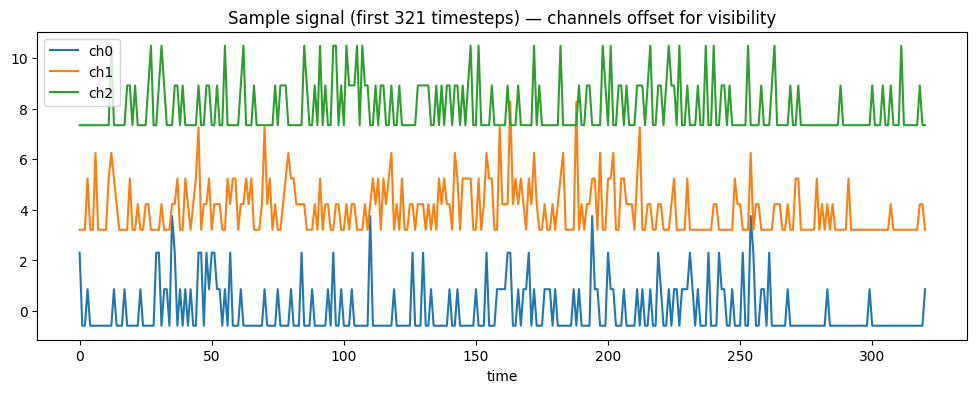

Transcript dataset shape: (500,)
First transcript (raw): 66


In [7]:
# Cell D: read one example, print transcript and plot a few channels/time-range
with h5py.File(sample_file, 'r') as hf:
    # Try to find likely dataset names that hold signals and labels
    # Common keys might be: 'neural_activity', 'signals', 'data', 'transcripts', 'labels', 'text'
    keys = list(hf.keys())
    print("File keys:", keys)

    # Heuristic: find first dataset with 2D shape (time x channels) or 3D (samples x time x channels)
    ds_candidates = []
    for k in keys:
        item = hf[k]
        if isinstance(item, h5py.Dataset):
            ds_candidates.append((k, item.shape))
        elif isinstance(item, h5py.Group):
            # look inside group
            for kk in item.keys():
                it = item[kk]
                if isinstance(it, h5py.Dataset):
                    ds_candidates.append((f"{k}/{kk}", it.shape))
    print("Dataset candidates (name, shape):")
    for name, shape in ds_candidates[:40]:
        print("-", name, shape)

    # Now try common names
    def try_get(path):
        try:
            return hf[path]
        except Exception:
            return None

    # Attempt patterns
    signal_ds = None
    transcript_ds = None
    # search dataset names for 'signal' or 'neural' or 'data'
    for name, shape in ds_candidates:
        lname = name.lower()
        if 'neural' in lname or 'signal' in lname or 'data' in lname or 'activity' in lname:
            # choose a candidate dataset with at least 2 dims
            arr = hf[name]
            if len(arr.shape) >= 2:
                signal_ds = name
                break
    # search for transcript/text label datasets
    for name, shape in ds_candidates:
        lname = name.lower()
        if 'trans' in lname or 'label' in lname or 'text' in lname or 'target' in lname:
            transcript_ds = name
            break

    print("Guessed signal dataset:", signal_ds)
    print("Guessed transcript dataset:", transcript_ds)

    # If signal_ds is a 3D dataset (N x T x C), load first sample; if 2D, treat as T x C
    if signal_ds is None:
        # fallback: pick the first dataset with 2+ dims
        for name, shape in ds_candidates:
            if len(shape) >= 2:
                signal_ds = name
                break
    if signal_ds is None:
        raise SystemExit("Couldn't locate a signal dataset automatically. Please inspect the file keys printed above.")

    sig = hf[signal_ds]
    print("signal dataset shape:", sig.shape)
    if len(sig.shape) == 3:
        # (N, T, C) or (N, C, T) - check typical ordering
        sample_signal = sig[0]  # first sample
    elif len(sig.shape) == 2:
        sample_signal = sig[:]   # whole array (T x C) or (samples x something) — we'll infer
    else:
        raise SystemExit("Signal dataset has unexpected number of dims:", sig.shape)

    # convert to numpy
    sample_signal = np.array(sample_signal)
    print("Loaded sample_signal shape:", sample_signal.shape)

    # If sample_signal shape is (T, C) we are good. If it's (C, T) transpose.
    if sample_signal.shape[0] < sample_signal.shape[1] and sample_signal.shape[0] < 10:
        # likely (channels, time) -> transpose
        sample_signal = sample_signal.T
        print("Transposed sample to shape (time, channels):", sample_signal.shape)

    # Print min/max and a small slice
    print("sample_signal dtype:", sample_signal.dtype, "min/max:", sample_signal.min(), sample_signal.max())
    t_len, n_ch = sample_signal.shape
    print(f"Time steps: {t_len}, Channels: {n_ch}")

    # Plot a few channels (first 3 channels) across a window (first 2000 timesteps or full if shorter)
    plt.figure(figsize=(12,4))
    ts = min(2000, t_len)
    for ch in range(min(3, n_ch)):
        plt.plot(sample_signal[:ts, ch] + ch* (np.std(sample_signal[:,ch])*4), label=f"ch{ch}")
    plt.title(f"Sample signal (first {ts} timesteps) — channels offset for visibility")
    plt.legend()
    plt.xlabel("time")
    plt.show()

    # Show transcript/target if found
    if transcript_ds:
        tr = np.array(hf[transcript_ds])
        print("Transcript dataset shape:", tr.shape)
        # try to print a first transcript if dataset is list-like
        try:
            # h5py can store variable-length strings; decode if bytes
            first = tr[0]
            if isinstance(first, bytes):
                first = first.decode('utf-8', errors='replace')
            print("First transcript (raw):", first)
        except Exception as e:
            print("Could not read a transcript entry directly:", e)
    else:
        print("No transcript dataset automatically found in this file (we'll search other files).")

phase 2

In [8]:
# PHASE 2 — Cell 1: Build an index of train HDF5 files
from pathlib import Path
import h5py
import pandas as pd
import json, tqdm

INPUT_DIR = Path('/kaggle/input/brain-to-text-25') / 't15_copyTask_neuralData' / 'hdf5_data_final'
assert INPUT_DIR.exists(), f"Expected dataset at {INPUT_DIR}, but not found."

# find all train files (files named like data_train.hdf5)
all_h5 = sorted([p for p in INPUT_DIR.rglob("data_train.hdf5")])
print("Found train hdf5 files:", len(all_h5))
all_h5[:5]

Found train hdf5 files: 45


[PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.13/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.18/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.20/data_train.hdf5'),
 PosixPath('/kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.25/data_train.hdf5')]

In [9]:
# PHASE 2 — Cell 2: Create a DataFrame index where each row = one trial
rows = []
for h5path in tqdm.tqdm(all_h5, desc="Scanning train hdf5 files"):
    with h5py.File(h5path, 'r') as hf:
        # list group names that start with 'trial_'
        for grp_name in hf.keys():
            if grp_name.startswith('trial_'):
                grp = hf[grp_name]
                if 'input_features' in grp:
                    try:
                        tshape = grp['input_features'].shape
                    except Exception:
                        tshape = None
                    rows.append({
                        'h5_path': str(h5path),
                        'group': grp_name,
                        'feat_shape': tshape
                    })

idx_df = pd.DataFrame(rows)
print("Total trials indexed:", len(idx_df))
display(idx_df.head())

# Save index for debugging / reproducibility
idx_df.to_csv('/kaggle/working/trial_index.csv', index=False)
print("Saved /kaggle/working/trial_index.csv")

Scanning train hdf5 files: 100%|██████████| 45/45 [00:17<00:00,  2.55it/s]

Total trials indexed: 8072


,h5_path,group,feat_shape
0,/kaggle/input/brain-to-text-25/t15_copyTask_ne...,trial_0000,"(321, 512)"
1,/kaggle/input/brain-to-text-25/t15_copyTask_ne...,trial_0001,"(481, 512)"
2,/kaggle/input/brain-to-text-25/t15_copyTask_ne...,trial_0002,"(480, 512)"
3,/kaggle/input/brain-to-text-25/t15_copyTask_ne...,trial_0003,"(502, 512)"
4,/kaggle/input/brain-to-text-25/t15_copyTask_ne...,trial_0004,"(402, 512)"


Saved /kaggle/working/trial_index.csv


In [10]:
# PHASE 2 — Cell 3: Streaming PyTorch Dataset (opens files lazily)
import torch, h5py, collections, numpy as np
from torch.utils.data import Dataset

class BrainDataset(Dataset):
    def __init__(self, index_df, cache_size=8, max_len=None):
        """
        index_df: DataFrame with ['h5_path', 'group']
        cache_size: number of open h5 files to keep cached (LRU)
        max_len: if set, center-crop time axis to this length
        """
        self.df = index_df.reset_index(drop=True)
        self.max_len = max_len
        self._cache_size = cache_size
        self._file_cache = collections.OrderedDict()

    def __len__(self):
        return len(self.df)

    def _open_file(self, path):
        # LRU cache for open HDF5 files
        if path in self._file_cache:
            self._file_cache.move_to_end(path)
            return self._file_cache[path]
        f = h5py.File(path, 'r')
        self._file_cache[path] = f
        if len(self._file_cache) > self._cache_size:
            old_path, old_f = self._file_cache.popitem(last=False)
            try:
                old_f.close()
            except:
                pass
        return f

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        f = self._open_file(row['h5_path'])
        g = f[row['group']]

        # EEG features [T, C] -> float32
        feats = g['input_features'][()].astype('float32')

        # target: 'transcription' preferred, else 'seq_class_ids'
        if 'transcription' in g:
            tgt = g['transcription'][()]
        elif 'seq_class_ids' in g:
            tgt = g['seq_class_ids'][()]
        else:
            raise KeyError(f"No target found in {row['h5_path']}::{row['group']}")

        # make 1D int array
        tgt = np.array(tgt, dtype='int64').reshape(-1)

        # trim trailing zeros (likely padding) if sequence is long
        if tgt.shape[0] >= 64:
            nz = np.nonzero(tgt)[0]
            if nz.size > 0:
                tgt = tgt[:nz[-1] + 1]
            else:
                tgt = tgt[:1]

        # optional center crop in time if max_len set
        if self.max_len and feats.shape[0] > self.max_len:
            start = (feats.shape[0] - self.max_len) // 2
            feats = feats[start:start + self.max_len]

        return torch.from_numpy(feats), torch.from_numpy(tgt)

    def close(self):
        # close cached files
        for _, f in list(self._file_cache.items()):
            try:
                f.close()
            except:
                pass
        self._file_cache.clear()

print("BrainDataset class ready.")

BrainDataset class ready.


In [11]:
# PHASE 2 — Cell 4: collate_fn for CTC
import torch
import torch.nn as nn

def collate_for_ctc(batch):
    """
    batch: list of tuples (feats_tensor [T,C], target_tensor [L])
    Returns:
      x_padded: [B, C, T_max]
      targets_concat: 1D tensor of concatenated targets
      input_lengths: tensor [B] lengths (in frames, i.e., T_i)
      target_lengths: tensor [B] lengths (L_i)
    """
    xs, ys = zip(*batch)
    x_lens = [x.shape[0] for x in xs]
    t_lens = [y.shape[0] for y in ys]

    max_t = max(x_lens)
    channels = xs[0].shape[1]
    x_padded = torch.zeros(len(xs), channels, max_t, dtype=torch.float32)
    for i, x in enumerate(xs):
        T = x.shape[0]
        # x is [T, C] -> convert to [C, T]
        x_padded[i, :, :T] = x.permute(1, 0)

    if sum(t_lens) > 0:
        targets_concat = torch.cat([y.to(torch.long) for y in ys])
    else:
        targets_concat = torch.tensor([], dtype=torch.long)

    return x_padded, targets_concat, torch.tensor(x_lens, dtype=torch.long), torch.tensor(t_lens, dtype=torch.long)

print("collate_for_ctc ready.")


collate_for_ctc ready.


In [12]:
# PHASE 2 — Cell 5: Build val index, create Dataset & DataLoader for train/val

# Build val index (scan data_val.hdf5)
val_h5 = sorted([p for p in INPUT_DIR.rglob("data_val.hdf5")])
print("Found val hdf5 files:", len(val_h5))

val_rows = []
for h5path in val_h5:
    with h5py.File(h5path, 'r') as hf:
        for grp_name in hf.keys():
            if grp_name.startswith('trial_') and 'input_features' in hf[grp_name]:
                val_rows.append({'h5_path': str(h5path), 'group': grp_name})

val_df = pd.DataFrame(val_rows)
print("Total val trials indexed:", len(val_df))

# Use the train index we built earlier (idx_df from Cell 2)
train_df_index = idx_df
print("Train trials:", len(train_df_index))

# Create dataset objects (optionally set max_len to limit memory; None = full length)
train_ds = BrainDataset(train_df_index, cache_size=12, max_len=None)
val_ds   = BrainDataset(val_df,         cache_size=4,  max_len=None)

from torch.utils.data import DataLoader

BATCH_SIZE  = 8      # keep same as before
NUM_WORKERS = 2

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_for_ctc,
    worker_init_fn=seed_worker,   # <- from Phase 0
    generator=g,                  # <- from Phase 0
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_for_ctc,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True
)

# sanity-check: load one batch
batch = next(iter(train_loader))
x_padded, targets_concat, input_lengths, target_lengths = batch
print("x_padded shape (B,C,T):", x_padded.shape)
print("targets_concat shape (sumL,):", targets_concat.shape)
print("input_lengths:", input_lengths)
print("target_lengths:", target_lengths)

# 🚫 DO NOT close train_ds / val_ds here — we will use them for training
# train_ds.close()
# val_ds.close()

print("Phase 2 complete: train/val datasets and dataloaders are ready.")

Found val hdf5 files: 41
Total val trials indexed: 1426
Train trials: 8072
x_padded shape (B,C,T): torch.Size([8, 512, 1686])
targets_concat shape (sumL,): torch.Size([216])
input_lengths: tensor([ 560,  736, 1178,  676,  885,  765, 1686,  693])
target_lengths: tensor([19, 20, 40, 20, 33, 25, 36, 23])
Phase 2 complete: train/val datasets and dataloaders are ready.


DATASET VISUALIZATION

In [13]:
# ===========================
# V1: Inspect one random trial
# ===========================
import random, h5py, numpy as np

def load_random_trial(df):
    """
    df: a DataFrame like idx_df or val_df with columns ['h5_path', 'group'].
    Returns: feats [T, C] float32, transcript_str
    """
    row = df.sample(1).iloc[0]
    h5_path = row["h5_path"]
    group = row["group"]

    with h5py.File(h5_path, "r") as hf:
        g = hf[group]
        feats = g["input_features"][()].astype("float32")  # [T, C]

        if "transcription" in g:
            trans = g["transcription"][()].astype("int32")
            # The dataset stores text as int32 ASCII codes (0 = padding)
            chars = [chr(c) for c in trans if c != 0]
            text = "".join(chars)
        else:
            text = "<no transcription found>"

    return feats, text, h5_path, group

# Use training index for visualization
feats_viz, text_viz, h5_path_viz, group_viz = load_random_trial(idx_df)

print("Random trial from:", h5_path_viz)
print("Group:", group_viz)
print("Features shape [T, C]:", feats_viz.shape)
print("Transcript:")
print(text_viz)

Random trial from: /kaggle/input/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.18/data_train.hdf5
Group: trial_0106
Features shape [T, C]: (934, 512)
Transcript:
I don't want to carry money around.


Time steps: 934, Channels/features: 512


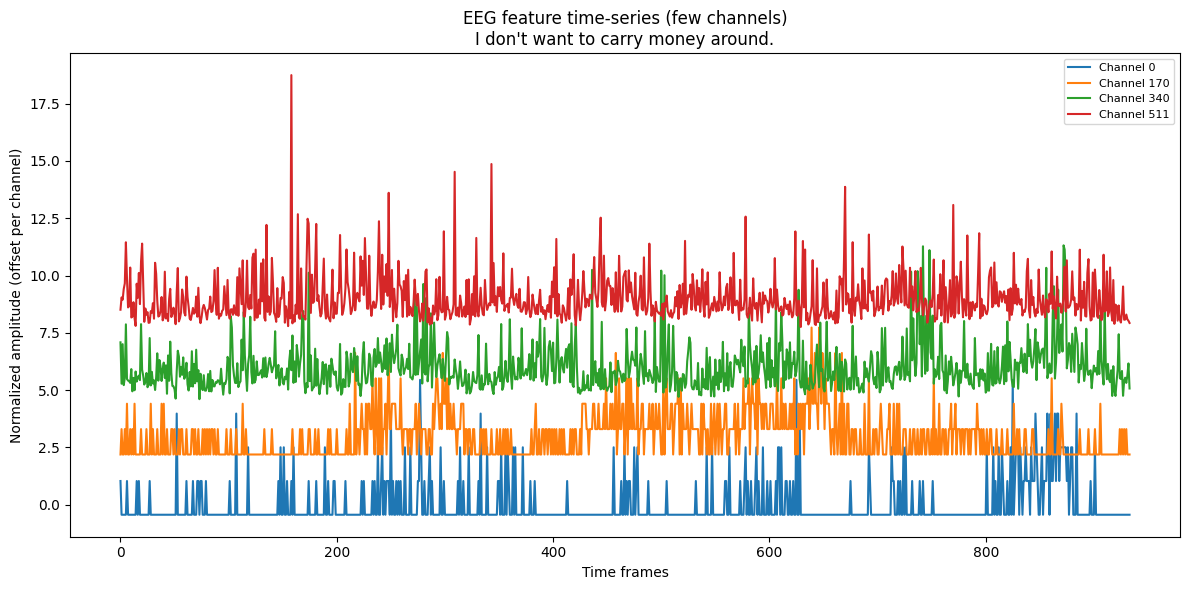

In [14]:
# ============================================
# V2: Plot time-series of a few feature channels
# ============================================
import matplotlib.pyplot as plt

T, C = feats_viz.shape
print(f"Time steps: {T}, Channels/features: {C}")

# Pick up to 4 channels spread across the feature dimension
num_channels_to_plot = 4
channel_indices = np.linspace(0, C - 1, num_channels_to_plot, dtype=int)

plt.figure(figsize=(12, 6))
time = np.arange(T)  # x-axis

offset = 0.0
offset_step = 3.0  # vertical offset between channels (for clarity)

for ch in channel_indices:
    # Take channel ch across time
    sig = feats_viz[:, ch]
    # Normalize per channel for nicer plotting
    sig_norm = (sig - sig.mean()) / (sig.std() + 1e-6)
    plt.plot(time, sig_norm + offset, label=f"Channel {ch}")
    offset += offset_step

plt.title("EEG feature time-series (few channels)\n" + text_viz)
plt.xlabel("Time frames")
plt.ylabel("Normalized amplitude (offset per channel)")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

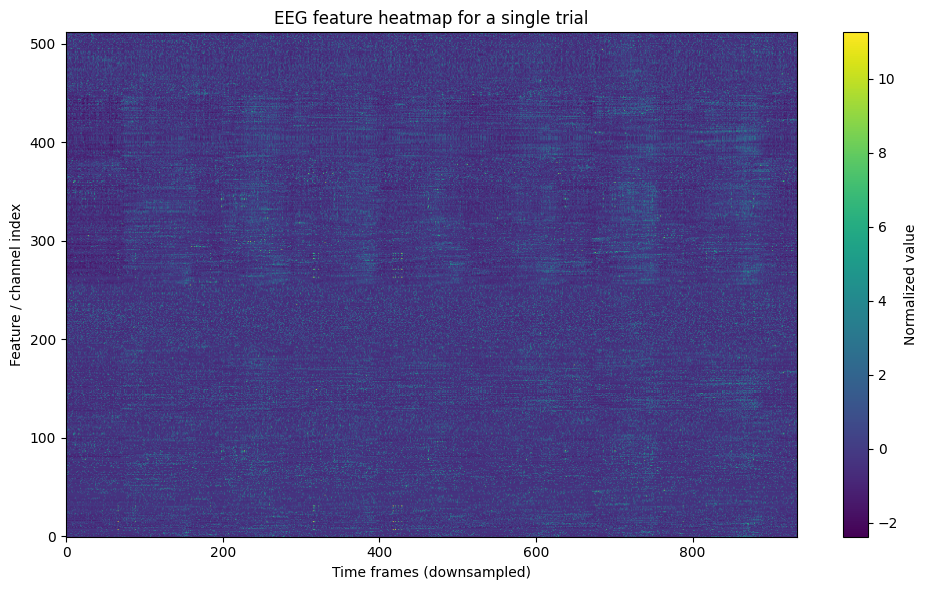

In [15]:
# ====================================
# V3: Heatmap of EEG features (T x C)
# ====================================
# Optionally downsample in time for faster plotting
max_T_for_plot = 800
if T > max_T_for_plot:
    step = T // max_T_for_plot
    feats_plot = feats_viz[::step]
else:
    feats_plot = feats_viz

# Normalize per-feature (channel) for better contrast
feats_norm = (feats_plot - feats_plot.mean(axis=0, keepdims=True)) / (
    feats_plot.std(axis=0, keepdims=True) + 1e-6
)

plt.figure(figsize=(10, 6))
plt.imshow(
    feats_norm.T,  # shape [C, T]
    aspect="auto",
    origin="lower",
)
plt.colorbar(label="Normalized value")
plt.xlabel("Time frames (downsampled)")
plt.ylabel("Feature / channel index")
plt.title("EEG feature heatmap for a single trial")
plt.tight_layout()
plt.show()


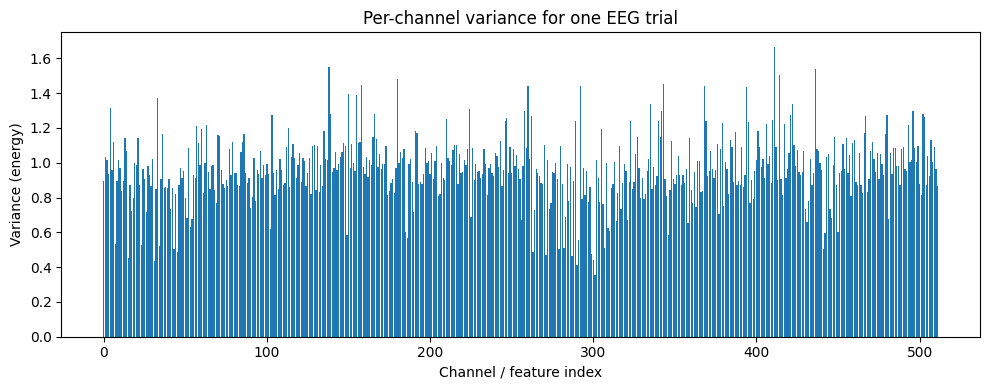

In [16]:
# ==========================================
# V4: Per-channel energy (variance) profile
# ==========================================
channel_var = feats_viz.var(axis=0)  # variance per feature/channel

plt.figure(figsize=(10, 4))
plt.bar(np.arange(C), channel_var)
plt.xlabel("Channel / feature index")
plt.ylabel("Variance (energy)")
plt.title("Per-channel variance for one EEG trial")
plt.tight_layout()
plt.show()

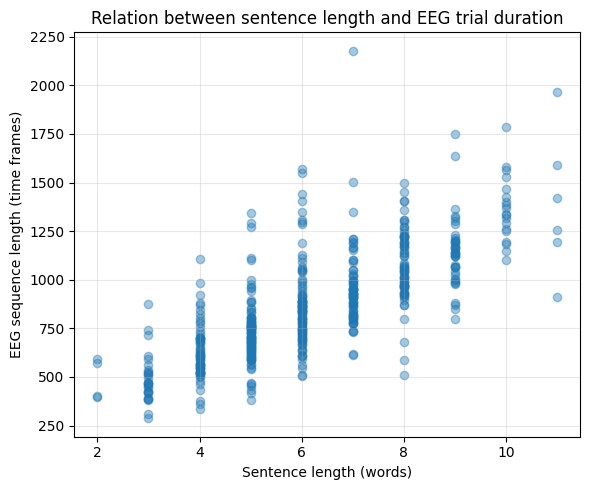

In [17]:
# ==================================================
# V5: Simple dataset analysis – length relationships
# ==================================================
lens_time = []
lens_text = []

sample_size = 500  # you can increase if GPU/CPU is okay

for i, (_, row) in enumerate(idx_df.sample(min(sample_size, len(idx_df))).iterrows()):
    with h5py.File(row["h5_path"], "r") as hf:
        g = hf[row["group"]]
        feats = g["input_features"][()]
        T_i = feats.shape[0]

        if "transcription" in g:
            trans = g["transcription"][()].astype("int32")
            text = "".join([chr(c) for c in trans if c != 0])
            L_i = len(text.split())  # word count
        else:
            L_i = 0

    lens_time.append(T_i)
    lens_text.append(L_i)

plt.figure(figsize=(6, 5))
plt.scatter(lens_text, lens_time, alpha=0.4)
plt.xlabel("Sentence length (words)")
plt.ylabel("EEG sequence length (time frames)")
plt.title("Relation between sentence length and EEG trial duration")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


phase 3

In [18]:
# Phase 3 - Cell 1: Define the Transformer model architecture
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# --- Positional Encoding (standard Transformer-style sine/cosine) ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [B, T, D]
        x = x + self.pe[:x.size(1)].unsqueeze(0)
        return x


# --- Convolutional Frontend (feature extractor + downsampler) ---
class ConvStem(nn.Module):
    def __init__(self, in_ch, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, d_model // 2, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv1d(d_model // 2, d_model, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

    def forward(self, x):
        # input: [B, C, T]
        return self.net(x)  # [B, D, T']


# --- Full Brain-to-Text Model ---
class BrainToTextModel(nn.Module):
    def __init__(self, in_ch=512, d_model=384, nhead=8, num_layers=6, vocab_size=200):
        super().__init__()
        self.conv = ConvStem(in_ch, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=d_model * 4, dropout=0.1, activation='relu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pos_enc = PositionalEncoding(d_model)
        self.fc = nn.Linear(d_model, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv1d):
            nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

    def forward(self, x):
        # x: [B, C, T]
        x = self.conv(x)          # [B, D, T']
        x = x.permute(0, 2, 1)    # [B, T', D]
        x = self.pos_enc(x)
        x = x.permute(1, 0, 2)    # [T', B, D] (required by Transformer)
        x = self.transformer(x)   # [T', B, D]
        x = x.permute(1, 0, 2)    # [B, T', D]
        logits = self.fc(x)       # [B, T', vocab_size]
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs

In [19]:
# Phase 3 - Cell 2: Initialize model, optimizer, scheduler, loss
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler

# detect input channels from one batch
sample_batch = next(iter(train_loader))
x_padded, targets_concat, input_lengths, target_lengths = sample_batch
in_channels = x_padded.shape[1]
print("Detected input channels:", in_channels)

# define model hyperparameters
vocab_size_estimate = 256  # since labels are already integer-encoded
model = BrainToTextModel(in_ch=in_channels, d_model=384, nhead=8,
                         num_layers=6, vocab_size=vocab_size_estimate).to('cuda')

# define loss, optimizer, scheduler
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = AdamW(model.parameters(), lr=3e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)
scaler = GradScaler()

print("Model initialized successfully.")
print("Total parameters:", sum(p.numel() for p in model.parameters())/1e6, "Million")

Detected input channels: 512


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Model initialized successfully.
Total parameters: 11.802688 Million


/tmp/ipykernel_55/2185077633.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [20]:
# =========================================================
# Phase 4 - Cell 1 (FINAL VERSION)
# Training & Validation loop with correct autocast + input_lengths fix
# =========================================================

import time, torch
from torch.amp import autocast
from tqdm import tqdm
import jiwer


# ------------------------ TRAIN ONE EPOCH ------------------------
def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch, device='cuda'):
    model.train()
    total_loss, steps = 0.0, 0
    start_time = time.time()

    for batch in tqdm(loader, desc=f"Epoch {epoch} [train]", leave=False):
        x, targets_concat, input_lengths, target_lengths = batch
        x, targets_concat = x.to(device), targets_concat.to(device)
        input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)

        # 🔧 Fix for ConvStem downsampling (stride 2 twice → /4)
        input_lengths = torch.div(input_lengths, 4, rounding_mode='floor')

        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', dtype=torch.float16):
            log_probs = model(x)                     # [B, T', V]
            log_probs = log_probs.permute(1, 0, 2)   # [T', B, V] for CTC
            loss = ctc_loss(log_probs, targets_concat, input_lengths, target_lengths)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        steps += 1

    avg_loss = total_loss / max(1, steps)
    print(f"Epoch {epoch}: train loss = {avg_loss:.4f}  (time {time.time() - start_time:.1f}s)")
    return avg_loss


# ------------------------ VALIDATE ------------------------
@torch.no_grad()
def validate(model, loader, epoch, device='cuda'):
    model.eval()
    total_loss, steps = 0.0, 0
    preds, refs = [], []

    for batch in tqdm(loader, desc=f"Epoch {epoch} [val]", leave=False):
        x, targets_concat, input_lengths, target_lengths = batch
        x, targets_concat = x.to(device), targets_concat.to(device)
        input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)

        # 🔧 Adjust lengths for ConvStem downsampling
        input_lengths = torch.div(input_lengths, 4, rounding_mode='floor')

        log_probs = model(x)
        log_probs = log_probs.permute(1, 0, 2)
        loss = ctc_loss(log_probs, targets_concat, input_lengths, target_lengths)
        total_loss += loss.item()
        steps += 1

        # --- Greedy decode for approximate WER ---
        decoded_batch = log_probs.argmax(-1).permute(1, 0).cpu().numpy()
        idx = 0
        for i, L in enumerate(target_lengths):
            true_seq = targets_concat[idx:idx + L].cpu().numpy().tolist()
            idx += L
            pred_seq = decoded_batch[i]
            # collapse repeats + remove blanks
            pred_seq_clean = [p for j, p in enumerate(pred_seq) if (j == 0 or p != pred_seq[j - 1]) and p != 0]
            ref_seq_clean = [p for p in true_seq if p != 0]
            preds.append(" ".join(map(str, pred_seq_clean)))
            refs.append(" ".join(map(str, ref_seq_clean)))

    val_loss = total_loss / max(1, steps)
    try:
        wer_score = jiwer.wer(refs, preds)
    except Exception:
        wer_score = None

    print(f"Epoch {epoch}: val loss = {val_loss:.4f},  WER ≈ {wer_score if wer_score else 'N/A'}")
    return val_loss, wer_score


# ------------------------ SAVE CHECKPOINT ------------------------
def save_checkpoint(model, optimizer, scheduler, epoch, path):
    ckpt = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }
    torch.save(ckpt, path)
    print(f"✅ Saved checkpoint: {path}")

In [21]:
# =========================================================
# Phase 5 (new run) - Training driver with:
#  - per-epoch checkpoints
#  - best-by-loss checkpoint
#  - best-by-WER checkpoint
# =========================================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_epochs = 30

best_val_loss = float('inf')
best_val_wer  = float('inf')

for epoch in range(1, num_epochs + 1):
    # 1) Train one epoch
    train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, epoch, device=device
    )

    # 2) Validate
    val_loss, val_wer = validate(
        model, val_loader, epoch, device=device
    )

    # 3) ALWAYS save this epoch (so you keep epoch 30, etc.)
    epoch_ckpt_path = f"/kaggle/working/model_epoch{epoch}.pt"
    save_checkpoint(model, optimizer, scheduler, epoch, epoch_ckpt_path)

    # 4) Track best-by-LOSS (optional but useful)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model, optimizer, scheduler, epoch,
            "/kaggle/working/model_best_loss.pt"
        )
        print(f"💾 Updated best-loss checkpoint at epoch {epoch} (val_loss={val_loss:.4f})")

    # 5) Track best-by-WER (MAIN metric for you now)
    if val_wer is not None and val_wer < best_val_wer:
        best_val_wer = val_wer
        save_checkpoint(
            model, optimizer, scheduler, epoch,
            "/kaggle/working/model_best_wer.pt"
        )
        print(f"🌟 Updated best-WER checkpoint at epoch {epoch} (WER={val_wer:.4f})")

print("Training complete ✅")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Best val WER : {best_val_wer:.4f}")

Epoch 1 [train]:   0%|          | 0/1009 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1: train loss = 3.9511  (time 129.5s)


Epoch 1: val loss = 3.0083,  WER ≈ 1.0
✅ Saved checkpoint: /kaggle/working/model_epoch1.pt
✅ Saved checkpoint: /kaggle/working/model_best_loss.pt
💾 Updated best-loss checkpoint at epoch 1 (val_loss=3.0083)
✅ Saved checkpoint: /kaggle/working/model_best_wer.pt
🌟 Updated best-WER checkpoint at epoch 1 (WER=1.0000)


Epoch 2: train loss = 2.6718  (time 128.8s)


Epoch 2: val loss = 2.3020,  WER ≈ 0.7460320723684211
✅ Saved checkpoint: /kaggle/working/model_epoch2.pt
✅ Saved checkpoint: /kaggle/working/model_best_loss.pt
💾 Updated best-loss checkpoint at epoch 2 (val_loss=2.3020)
✅ Saved checkpoint: /kaggle/working/model_best_wer.pt
🌟 Updated best-WER checkpoint at epoch 2 (WER=0.7460)


...

Epoch 28: val loss = 1.8099,  WER ≈ 0.3638157894736842
✅ Saved checkpoint: /kaggle/working/model_epoch28.pt


Epoch 29: train loss = 0.2354  (time 139.0s)


Epoch 29: val loss = 1.8541,  WER ≈ 0.35633223684210524
✅ Saved checkpoint: /kaggle/working/model_epoch29.pt
✅ Saved checkpoint: /kaggle/working/model_best_wer.pt
🌟 Updated best-WER checkpoint at epoch 29 (WER=0.3563)


Epoch 30: train loss = 0.2534  (time 136.3s)


Epoch 30: val loss = 1.9114,  WER ≈ 0.3623972039473684
✅ Saved checkpoint: /kaggle/working/model_epoch30.pt
Training complete ✅
Best val loss: 1.4123
Best val WER : 0.3563


In [40]:
print([k for k in globals().keys() if "char" in k.lower() or "token" in k.lower() or "vocab" in k.lower()])


['vocab_size_estimate']


In [41]:
import json

config = {
    "vocab_size": vocab_size_estimate,
    "ctc_blank_index": 0,
    "decoding": "beam_search",
    "beam_width": 10  # or whatever you use
}

with open("/kaggle/working/neurovaani_config.json", "w") as f:
    json.dump(config, f, indent=2)


In [22]:
1+1

2

In [23]:
import os
print(os.listdir("/kaggle/working"))

['model_epoch1.pt', 'model_epoch15.pt', 'model_epoch14.pt', 'model_epoch24.pt', 'model_epoch10.pt', 'model_epoch7.pt', 'model_epoch16.pt', 'model_epoch20.pt', 'model_epoch27.pt', 'model_epoch29.pt', 'model_epoch22.pt', 'model_epoch30.pt', 'model_best_loss.pt', 'model_epoch9.pt', 'model_epoch13.pt', 'model_epoch28.pt', 'model_epoch2.pt', 'trial_index.csv', 'model_epoch25.pt', '.virtual_documents', 'model_epoch17.pt', 'model_epoch18.pt', 'model_epoch6.pt', 'model_epoch19.pt', 'model_epoch4.pt', 'model_epoch3.pt', 'model_epoch5.pt', 'model_epoch23.pt', 'model_epoch26.pt', 'model_best_wer.pt', 'model_epoch8.pt', 'model_epoch21.pt', 'model_epoch12.pt', 'model_epoch11.pt']


In [24]:
# =========================================================
# Phase 5 - Cell 1 (updated for new run)
# Load the best-WER model checkpoint for inference
# =========================================================

import torch

# ✅ Use the best-WER checkpoint saved in Phase 5 training
best_ckpt_path = "/kaggle/working/model_best_wer.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading checkpoint from: {best_ckpt_path}")
ckpt = torch.load(best_ckpt_path, map_location=device)

# Load model weights and set up for inference
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

print(f"✅ Model loaded successfully from {best_ckpt_path}")
print(f"Device in use: {device}")


Loading checkpoint from: /kaggle/working/model_best_wer.pt
✅ Model loaded successfully from /kaggle/working/model_best_wer.pt
Device in use: cuda


In [25]:
# =========================================================
# Phase 5 - Cell 2
# Find all test .hdf5 files for inference
# =========================================================

from pathlib import Path

# We already have INPUT_DIR defined from Phase 2
# (the folder containing all hdf5_data_final/ files)
test_files = sorted([p for p in INPUT_DIR.rglob("data_test.hdf5")])

print(f"✅ Found {len(test_files)} test files.\n")
print("Example test files:")
for f in test_files[:10]:
    print("-", f.relative_to(INPUT_DIR))

✅ Found 41 test files.

Example test files:
- t15.2023.08.13/data_test.hdf5
- t15.2023.08.18/data_test.hdf5
- t15.2023.08.20/data_test.hdf5
- t15.2023.08.25/data_test.hdf5
- t15.2023.08.27/data_test.hdf5
- t15.2023.09.01/data_test.hdf5
- t15.2023.09.03/data_test.hdf5
- t15.2023.09.24/data_test.hdf5
- t15.2023.09.29/data_test.hdf5
- t15.2023.10.01/data_test.hdf5


In [26]:
# =========================================================
# Phase 5 - Cell 3
# Helper functions for inference and greedy decoding
# =========================================================

import torch
import numpy as np
import h5py
from pathlib import Path
from torch.amp import autocast

@torch.no_grad()
def greedy_decode(log_probs):
    """
    Performs greedy decoding of log probabilities.
    Removes blanks (0) and repeated tokens.
    Args:
        log_probs: [B, T', V] tensor
    Returns:
        List of integer token sequences
    """
    preds = log_probs.argmax(-1).cpu().numpy()  # [B, T']
    decoded = []
    for i in range(preds.shape[0]):
        seq = preds[i]
        seq_clean = [p for j, p in enumerate(seq)
                     if (j == 0 or p != seq[j - 1]) and p != 0]
        decoded.append(seq_clean)
    return decoded


@torch.no_grad()
def infer_file(model, path, device="cuda"):
    """
    Runs inference on all trials inside one HDF5 test file.
    Args:
        model: trained BrainToTextModel
        path: path to .hdf5 file
        device: 'cuda' or 'cpu'
    Returns:
        List of dicts: [{'id': '<filename>_<trial>', 'transcript': '<decoded tokens>'}, ...]
    """
    preds_list = []
    with h5py.File(path, "r") as hf:
        for trial in hf.keys():
            if "input_features" not in hf[trial]:
                continue

            feats = hf[trial]["input_features"][()].astype("float32")
            x = torch.from_numpy(feats).unsqueeze(0).permute(0, 2, 1).to(device)  # [1, C, T]

            with autocast("cuda", dtype=torch.float16):
                log_probs = model(x)  # [1, T', V]

            decoded = greedy_decode(log_probs)[0]
            decoded_str = " ".join(map(str, decoded))

            preds_list.append({
                "id": f"{Path(path).stem}_{trial}",
                "transcript": decoded_str
            })

    return preds_list


In [27]:
# =========================================================
# Phase 5 - Cell 4
# Run inference on all test files and collect predictions
# =========================================================

import pandas as pd
from tqdm import tqdm

all_preds = []

print(" Running inference on test set...")
for test_path in tqdm(test_files, desc="Inference progress"):
    preds = infer_file(model, test_path, device=device)
    all_preds.extend(preds)

# Convert all predictions into a DataFrame
sub_df = pd.DataFrame(all_preds)
print(f"\n✅ Inference complete. Total predictions: {len(sub_df)}")

# Show a small preview
display(sub_df.head(10))

 Running inference on test set...


Inference progress: 100%|██████████| 41/41 [00:37<00:00,  1.09it/s]


✅ Inference complete. Total predictions: 1450


,id,transcript
0,data_test_trial_0000,73 32 103 111 117 116 32 116 105 101 114 101 1...
1,data_test_trial_0001,69 109 111 114 99 115 32 99 104 101 114 101 46
2,data_test_trial_0002,89 111 117 32 114 114 101 114 101 116 32 97 32...
3,data_test_trial_0003,73 32 116 104 105 110 107 32 102 97 109 121 32...
4,data_test_trial_0004,83 111 32 116 104 97 116 32 116 104 101 97 121...
5,data_test_trial_0005,73 32 101 110 106 111 101 121 32 116 104 97 11...
6,data_test_trial_0006,73 32 109 111 118 101 116 32 116 111 32 103 10...
7,data_test_trial_0007,77 97 116 98 114 32 102 111 114 32 105 109 101...
8,data_test_trial_0008,87 104 101 110 32 104 105 32 103 105 115 32 10...
9,data_test_trial_0009,84 104 101 114 101 39 115 44 32 106 106 117 11...


In [28]:
# =========================================================
# Phase 5 - Cell 5
# Save predictions as submission.csv
# =========================================================
sub_path = "/kaggle/working/submission.csv"
sub_df.to_csv(sub_path, index=False)

print(f"✅ Submission file saved successfully at: {sub_path}")
print("Preview:")
display(sub_df.head(10))


✅ Submission file saved successfully at: /kaggle/working/submission.csv
Preview:


,id,transcript
0,data_test_trial_0000,73 32 103 111 117 116 32 116 105 101 114 101 1...
1,data_test_trial_0001,69 109 111 114 99 115 32 99 104 101 114 101 46
2,data_test_trial_0002,89 111 117 32 114 114 101 114 101 116 32 97 32...
3,data_test_trial_0003,73 32 116 104 105 110 107 32 102 97 109 121 32...
4,data_test_trial_0004,83 111 32 116 104 97 116 32 116 104 101 97 121...
5,data_test_trial_0005,73 32 101 110 106 111 101 121 32 116 104 97 11...
6,data_test_trial_0006,73 32 109 111 118 101 116 32 116 111 32 103 10...
7,data_test_trial_0007,77 97 116 98 114 32 102 111 114 32 105 109 101...
8,data_test_trial_0008,87 104 101 110 32 104 105 32 103 105 115 32 10...
9,data_test_trial_0009,84 104 101 114 101 39 115 44 32 106 106 117 11...


In [29]:
# =========================================================
# Phase 6: Show sample predictions (actual vs predicted)
# (integer tokens)
# =========================================================
import random
from torch.amp import autocast

# Pick a few random validation files
val_files = sorted([p for p in INPUT_DIR.rglob("data_val.hdf5")])
print(f"Found {len(val_files)} validation files.")
sample_files = random.sample(val_files, 3)  # show samples from 3 val files

for val_path in sample_files:
    print(f"\n File: {val_path.name}")
    with h5py.File(val_path, "r") as hf:
        # Pick 2 random trials from each file
        trial_names = random.sample(list(hf.keys()), 2)
        for trial in trial_names:
            if "input_features" not in hf[trial]:
                continue
            feats = hf[trial]["input_features"][()].astype("float32")
            transcript = hf[trial]["transcription"][()].astype("int32")

            # Decode transcript (true)
            true_text = " ".join(map(str, transcript.tolist()))

            # Model prediction
            x = torch.from_numpy(feats).unsqueeze(0).permute(0, 2, 1).to(device)
            with autocast("cuda", dtype=torch.float16):
                log_probs = model(x)
            decoded_seq = greedy_decode(log_probs)[0]
            pred_text = " ".join(map(str, decoded_seq))

            print(f" Trial: {trial}")
            print(f"   ➤ Predicted: {pred_text[:200]}...")
            print(f"   ➤ Actual:    {true_text[:200]}...\n")

Found 41 validation files.

 File: data_val.hdf5
 Trial: trial_0023
   ➤ Predicted: 87 111 32 118 101 109 32 116 97 110 32 103 97 116 32 32 32 119 111 109 46...
   ➤ Actual:    67 111 118 101 114 32 104 105 109 32 117 112 32 97 110 100 32 107 101 101 112 32 104 105 109 32 119 97 114 109 46 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...

 Trial: trial_0008
   ➤ Predicted: 73 73 32 119 97 116 32 116 104 101 116 116 104 32 116 111 32 116 111 109 101 32 98 32 111 117 112 32 111 115 32 121 101 97 114 46...
   ➤ Actual:    73 32 119 97 110 116 32 116 104 101 109 32 116 111 32 99 111 109 101 32 98 97 99 107 32 117 112 32 110 101 120 116 32 121 101 97 114 46 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...


 File: data_val.hdf5
 Trial: trial_0015
   ➤ Predicted: 87 104 97 115 32 116 104 105 115 32 105 115 32 101 110 116 111 101 32 102 97 109 105 108 121 63...
   ➤ Actual:    87 97 115 32 116 104 105 115 32 104 105 115 32 101 110 11

In [30]:
# =========================================================
# Convert integer predictions & actuals to readable text
# =========================================================

def decode_ascii(int_seq):
    """Convert list/array of integers to readable text (ASCII decoding)."""
    chars = [chr(i) for i in int_seq if 32 <= i <= 126]  # printable characters
    return "".join(chars)

# Display a few samples again in readable form
val_path = random.choice(val_files)
print(f"\n📘 File: {val_path.name}")

with h5py.File(val_path, "r") as hf:
    trial_names = random.sample(list(hf.keys()), 10)
    for trial in trial_names:
        if "input_features" not in hf[trial]:
            continue

        feats = hf[trial]["input_features"][()].astype("float32")
        transcript = hf[trial]["transcription"][()].astype("int32")

        # Run prediction
        x = torch.from_numpy(feats).unsqueeze(0).permute(0, 2, 1).to(device)
        with autocast("cuda", dtype=torch.float16):
            log_probs = model(x)
        decoded_seq = greedy_decode(log_probs)[0]

        # Decode to readable text
        pred_text = decode_ascii(decoded_seq)
        true_text = decode_ascii(transcript.tolist())

        print(f" Trial: {trial}")
        print(f"   ➤ Predicted: {pred_text}")
        print(f"   ➤ Actual:    {true_text}\n")


📘 File: data_val.hdf5
 Trial: trial_0005
   ➤ Predicted: You don'tt feerl spaper colln.
   ➤ Actual:    You don't feel super cold.

 Trial: trial_0027
   ➤ Predicted: That kind of though them of.
   ➤ Actual:    That kind of threw them off.

 Trial: trial_0002
   ➤ Predicted: You haved to wi throgh.
   ➤ Actual:    You have to fly through.

 Trial: trial_0000
   ➤ Predicted: Aing nethe an maekig amets on them.
   ➤ Actual:    Owning on them and making payments on them.

 Trial: trial_0031
   ➤ Predicted: I don't yeare fworr that at all.
   ➤ Actual:    I don't care for that at all.

 Trial: trial_0006
   ➤ Predicted: What e the prapserisrs with poablaeaneaeton?
   ➤ Actual:    What are the problems with public education?

 Trial: trial_0007
   ➤ Predicted: O will go pont it qealloy onn the paest?
   ➤ Actual:    Oh well, no point in dwelling on the past.

 Trial: trial_0016
   ➤ Predicted: Bay am eisestte an you now.
   ➤ Actual:    Pay and exhaustion and you know.

 Trial: trial_0019

BEAM SEARCH

In [31]:
# =========================================================
# Beam Search Decoder for CTC (no LM)
# =========================================================
import math
import torch

def log_sum_exp_scalar(a, b):
    if a == -float("inf"):
        return b
    if b == -float("inf"):
        return a
    if a > b:
        return a + math.log1p(math.exp(b - a))
    else:
        return b + math.log1p(math.exp(a - b))

def ctc_beam_search(log_probs_t_v, beam_width=10, blank_id=0):
    T, V = log_probs_t_v.shape
    beams = {(): (0.0, -float("inf"))}

    for t in range(T):
        next_beams = {}
        lp = log_probs_t_v[t]

        for prefix, (pb, pnb) in beams.items():
            for c in range(V):
                p = lp[c].item()

                if c == blank_id:
                    nb = log_sum_exp_scalar(pb + p, pnb + p)
                    old_pb, old_pnb = next_beams.get(prefix, (-float("inf"), -float("inf")))
                    next_beams[prefix] = (log_sum_exp_scalar(old_pb, nb), old_pnb)
                else:
                    end = prefix[-1] if prefix else None

                    if c == end:
                        new_prefix = prefix
                        nb_pnb = pnb + p
                        old_pb, old_pnb = next_beams.get(new_prefix, (-float("inf"), -float("inf")))
                        next_beams[new_prefix] = (old_pb, log_sum_exp_scalar(old_pnb, nb_pnb))
                    else:
                        new_prefix = prefix + (c,)
                        nb_pnb = log_sum_exp_scalar(pb + p, pnb + p)
                        old_pb, old_pnb = next_beams.get(new_prefix, (-float("inf"), -float("inf")))
                        next_beams[new_prefix] = (old_pb, log_sum_exp_scalar(old_pnb, nb_pnb))

        beams = dict(
            sorted(
                next_beams.items(),
                key=lambda kv: log_sum_exp_scalar(kv[1][0], kv[1][1]),
                reverse=True
            )[:beam_width]
        )

    best_prefix, (pb, pnb) = max(
        beams.items(),
        key=lambda kv: log_sum_exp_scalar(kv[1][0], kv[1][1])
    )
    return list(best_prefix)


@torch.no_grad()
def beam_search_decode_batch(log_probs_t_b_v, beam_width=10, blank_id=0):
    T, B, V = log_probs_t_b_v.shape
    decoded = []
    for b in range(B):
        seq = ctc_beam_search(log_probs_t_b_v[:, b, :], beam_width=beam_width, blank_id=blank_id)
        decoded.append(seq)
    return decoded

In [32]:
# ------------------------ VALIDATE (beam search, beam_width=10, MAX_VAL=20) ------------------------
@torch.no_grad()
def validate(model, loader, epoch, device='cuda'):
    model.eval()
    total_loss, steps = 0.0, 0
    preds, refs = [], []

    MAX_VAL_BATCHES = 20  # <- use 20 validation batches

    for batch_i, batch in enumerate(
        tqdm(loader, total=MAX_VAL_BATCHES, desc=f"Epoch {epoch} [val]", leave=False)
    ):
        # stop after MAX_VAL_BATCHES
        if batch_i >= MAX_VAL_BATCHES:
            break

        x, targets_concat, input_lengths, target_lengths = batch
        x, targets_concat = x.to(device), targets_concat.to(device)
        input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)

        # adjust for /4 downsampling (same as training)
        input_lengths = torch.div(input_lengths, 4, rounding_mode='floor')

        # forward
        log_probs = model(x)                    # [B, T', V]
        log_probs = log_probs.permute(1, 0, 2)  # [T', B, V]

        # CTC loss
        loss = ctc_loss(log_probs, targets_concat, input_lengths, target_lengths)
        total_loss += loss.item()
        steps += 1

        # 🔹 beam search decode (beam_width = 10)
        decoded_batch = beam_search_decode_batch(
            log_probs, beam_width=10, blank_id=0
        )  # list[list[int]]

        idx = 0
        for i, L in enumerate(target_lengths):
            true_seq = targets_concat[idx:idx + L].cpu().numpy().tolist()
            idx += L

            pred_seq = decoded_batch[i]
            ref_seq_clean = [p for p in true_seq if p != 0]

            preds.append(" ".join(map(str, pred_seq)))
            refs.append(" ".join(map(str, ref_seq_clean)))

    val_loss = total_loss / max(1, steps)

    try:
        wer_score = jiwer.wer(refs, preds)
    except Exception:
        wer_score = None

    print(f"Epoch {epoch}: val loss = {val_loss:.4f},  WER ≈ {wer_score}")
    return val_loss, wer_score

In [33]:
val_loss, val_wer = validate(model, val_loader, epoch=999, device=device)

Epoch 999: val loss = 1.6108,  WER ≈ 0.2910063799135625


In [34]:
# =========================================================
# Phase 6: Show sample predictions (actual vs predicted)
# (integer tokens) - BEAM SEARCH VERSION
# =========================================================
import random
from torch.amp import autocast

# Pick a few random validation files
val_files = sorted([p for p in INPUT_DIR.rglob("data_val.hdf5")])
print(f"Found {len(val_files)} validation files.")
sample_files = random.sample(val_files, 3)  # show samples from 3 val files

for val_path in sample_files:
    print(f"\n File: {val_path.name}")
    with h5py.File(val_path, "r") as hf:
        # Pick 2 random trials from each file
        trial_names = random.sample(list(hf.keys()), 2)
        for trial in trial_names:
            if "input_features" not in hf[trial]:
                continue
            feats = hf[trial]["input_features"][()].astype("float32")
            transcript = hf[trial]["transcription"][()].astype("int32")

            # Decode transcript (true)
            true_text = " ".join(map(str, transcript.tolist()))

            # Model prediction
            x = torch.from_numpy(feats).unsqueeze(0).permute(0, 2, 1).to(device)
            with autocast("cuda", dtype=torch.float16):
                log_probs = model(x)          # [1, T', V]

            # 👉 Beam search instead of greedy
            log_probs_seq = log_probs[0].cpu()   # [T', V]
            decoded_seq = ctc_beam_search(
                log_probs_seq,
                beam_width=10,
                blank_id=0
            )

            pred_text = " ".join(map(str, decoded_seq))

            print(f" Trial: {trial}")
            print(f"   ➤ Predicted: {pred_text[:200]}...")
            print(f"   ➤ Actual:    {true_text[:200]}...\n")

Found 41 validation files.

 File: data_val.hdf5
 Trial: trial_0013
   ➤ Predicted: 73 116 32 100 111 116 32 116 104 97 101 105 115 116 97 103 115 112 97 121 104 103 46...
   ➤ Actual:    73 32 100 111 110 39 116 32 107 110 111 119 32 105 102 32 105 116 39 115 32 116 104 97 116 32 115 101 114 105 111 117 115 46 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...

 Trial: trial_0007
   ➤ Predicted: 84 104 121 32 115 97 116 32 104 97 101 115 101 32 111 103 32 98 97 104 121 105 116 101 116 32 116 104 101 111 97 101 46...
   ➤ Actual:    84 104 101 121 32 115 101 110 116 32 117 115 32 97 32 108 105 116 116 108 101 32 98 111 111 107 108 101 116 32 116 111 32 114 101 97 100 46 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...


 File: data_val.hdf5
 Trial: trial_0028
   ➤ Predicted: 65 97 99 97 116 121 32 99 111 110 118 109 110 115 105 111 109 32 111 99 97 32 102 114 111 114 115 116 32 114 101 115 101 97 112 116 108 32 99 111 108...
   ➤ Actual:    99

In [38]:
# =========================================================
# Convert integer predictions & actuals to readable text
# (using BEAM SEARCH for decoding)
# =========================================================

def decode_ascii(int_seq):
    """Convert list/array of integers to readable text (ASCII decoding)."""
    chars = [chr(i) for i in int_seq if 32 <= i <= 126]  # printable characters
    return "".join(chars)

# Display a few samples again in readable form
val_path = random.choice(val_files)
print(f"\n📘 File: {val_path.name}")

with h5py.File(val_path, "r") as hf:
    trial_names = random.sample(list(hf.keys()), 10)
    for trial in trial_names:
        if "input_features" not in hf[trial]:
            continue

        feats = hf[trial]["input_features"][()].astype("float32")
        transcript = hf[trial]["transcription"][()].astype("int32")

        # Run prediction
        x = torch.from_numpy(feats).unsqueeze(0).permute(0, 2, 1).to(device)
        with autocast("cuda", dtype=torch.float16):
            log_probs = model(x)          # [1, T', V]

        # 👉 Beam search instead of greedy
        log_probs_seq = log_probs[0].cpu()   # [T', V]
        decoded_seq = ctc_beam_search(
            log_probs_seq,
            beam_width=10,
            blank_id=0
        )

        # Decode to readable text
        pred_text = decode_ascii(decoded_seq)
        true_text = decode_ascii(transcript.tolist())

        print(f" Trial: {trial}")
        print(f"   ➤ Predicted: {pred_text}")
        print(f"   ➤ Actual:    {true_text}\n")


📘 File: data_val.hdf5
 Trial: trial_0042
   ➤ Predicted: Asine the beultig it's not bad.
   ➤ Actual:    Outside the building it's not bad.

 Trial: trial_0014
   ➤ Predicted: Cope of hortret kuits in the pat.
   ➤ Actual:    Couple of hundred kids in the band.

 Trial: trial_0018
   ➤ Predicted: We went to olata precs.
   ➤ Actual:    We went to Colorado Springs.

 Trial: trial_0005
   ➤ Predicted: I thnk the loeaves i are last tdefiud.
   ➤ Actual:    I think the roles now are less defined.

 Trial: trial_0046
   ➤ Predicted: It's nefcale to realy sa why.
   ➤ Actual:    It's difficult to really say why.

 Trial: trial_0006
   ➤ Predicted: We sterted daking her.
   ➤ Actual:    We started taking her.

 Trial: trial_0024
   ➤ Predicted: What's the firtuin. were wron
   ➤ Actual:    Once the children were grown.

 Trial: trial_0017
   ➤ Predicted: I know i've had this ione lite that was tat.
   ➤ Actual:    I know we've had this one lady that was attacked.

 Trial: trial_0029
   ➤ Pre